# symbolic regression with a neural network, without and with a pinn

this notebook has two parts.

- **part a (no pinn):** the workshop pipeline. random expression trees, tokenization, and a small network that predicts an expression one token at a time from 100 data points.
- **part b (with pinn):** the same trained network, but now the observations are sparse and noisy. a physics-informed neural network (pinn) first reconstructs the function using a known ode, and the reconstruction is passed to the symbolic regression network.

**an important assumption for part b:** the pinn needs some known physics. here we assume we know the derivative law dy/dx = s(x) (for example, a known velocity law while we only measured noisy positions). without a known equation like this, a pinn has nothing to enforce, which is why part a does not use one.

In [1]:
import random
import time
import numpy as np
import sympy as sp
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## part a: symbolic regression without a pinn

### a1. expression trees

In [2]:
# x is real so that sympy can differentiate abs() cleanly later on
x = sp.Symbol("x", real=True)

# binary operators take two children, unary operators take one
binary_ops = {
    "+": lambda a, b: a + b,
    "-": lambda a, b: a - b,
    "*": lambda a, b: a * b,
}
unary_ops = {
    "abs": sp.Abs,
    "sin": sp.sin,
    "tan": sp.tan,
    "exp": sp.exp,
}


class TreeNode:
    def __init__(self, val=None, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right


def make_binary_tree(n_ops):
    # a tree with zero operators is just the leaf x
    if n_ops == 0:
        return "x"
    node = TreeNode(random.choice(list(binary_ops)))
    left_ops = random.randint(0, n_ops - 1)
    node.left = make_binary_tree(left_ops)
    node.right = make_binary_tree(n_ops - 1 - left_ops)
    return node


def add_unary_ops(root, n_ops):
    # collect every internal node so we can wrap any of them
    nodes = []

    def collect(node):
        if isinstance(node, TreeNode):
            nodes.append(node)
            collect(node.left)
            collect(node.right)

    collect(root)

    for _ in range(n_ops):
        target = random.choice(nodes)
        # copy the old node, then turn the target into a unary node above the copy
        # this way we never need to search for the parent of the target
        old = TreeNode(target.val, target.left, target.right)
        target.val = random.choice(list(unary_ops))
        target.left = old
        target.right = None
        nodes.append(old)
    return root


def tree_to_sympy(node):
    if not isinstance(node, TreeNode):
        return x
    if node.val in binary_ops:
        return binary_ops[node.val](tree_to_sympy(node.left), tree_to_sympy(node.right))
    return unary_ops[node.val](tree_to_sympy(node.left))


def tree_to_prefix(node):
    # node first, then left, then right. a missing right child of a unary node becomes none
    if isinstance(node, TreeNode):
        return [node.val] + tree_to_prefix(node.left) + tree_to_prefix(node.right)
    return [node]


def prefix_to_tree(seq):
    # rebuilds a tree and raises an error if the sequence is not a valid expression
    it = iter(seq)

    def build(expect_none=False):
        val = next(it)
        if expect_none:
            if val is not None:
                raise ValueError("expected none")
            return None
        if val in binary_ops:
            return TreeNode(val, build(), build())
        if val in unary_ops:
            return TreeNode(val, build(), build(expect_none=True))
        if val == "x":
            return "x"
        raise ValueError("bad token")

    root = build()
    if next(it, "done") != "done":
        raise ValueError("extra tokens")
    return root


# quick check: x * sin(x + x)
demo = TreeNode("*", "x", TreeNode("sin", TreeNode("+", "x", "x"), None))
print(tree_to_prefix(demo))
print(tree_to_sympy(demo))
print(tree_to_sympy(prefix_to_tree(tree_to_prefix(demo))))

['*', 'x', 'sin', '+', 'x', 'x', None]
x*sin(2*x)
x*sin(2*x)


### a2. building the dataset

In [3]:
x_grid = np.linspace(-1, 1, 100)


def evaluate(expr, xs):
    # lambdify returns a plain number for constants, so we broadcast to the grid shape
    fn = sp.lambdify(x, expr, modules="numpy")
    with np.errstate(all="ignore"):
        y = fn(xs)
    return np.broadcast_to(np.asarray(y, dtype=float), xs.shape).copy()


n_trees = 150000
seen = set()
trees, exprs, ys = [], [], []

start = time.time()
for _ in range(n_trees):
    root = make_binary_tree(random.randint(1, 3))
    root = add_unary_ops(root, random.randint(1, 2))
    expr = tree_to_sympy(root)

    # skip constants, and skip duplicates (sympy writes equal expressions the same way)
    if not expr.free_symbols:
        continue
    key = str(expr)
    if key in seen:
        continue

    # skip extreme expressions
    y = evaluate(expr, x_grid)
    if not np.all(np.isfinite(y)) or np.max(np.abs(y)) >= 10:
        continue

    seen.add(key)
    trees.append(root)
    exprs.append(expr)
    ys.append(y)

print(f"kept {len(trees)} unique expressions out of {n_trees} in {time.time() - start:.0f}s")
print(exprs[:8])

kept 2058 unique expressions out of 150000 in 52s
[x - sin(1), x**2 + 2*Abs(x), 2*x*Abs(x), 2*x - sin(x**2), 2*x - exp(sin(x**2)), sin(tan(x**2)), sin(2*Abs(x)), sin(tan(2*x))]


### a3. tokenization

In [4]:
vocab = list(binary_ops) + list(unary_ops) + ["x", None, "<eos>", "<pad>"]
tok = {sym: i for i, sym in enumerate(vocab)}
n_tokens = len(vocab)
EOS, PAD = tok["<eos>"], tok["<pad>"]
print(tok)

seqs = [[tok[s] for s in tree_to_prefix(t)] for t in trees]
lengths = np.array([len(s) for s in seqs])

# longest expression plus one slot for the end token
T = lengths.max() + 1
print("max sequence length T:", T)

# pad every sequence with eos up to the max length
vecs = np.full((len(seqs), T), EOS, dtype=np.int64)
for i, s in enumerate(seqs):
    vecs[i, :len(s)] = s

# data tensor of shape (n, 100, 2) holding the (x, f(x)) pairs
data = np.stack([np.tile(x_grid, (len(ys), 1)), np.array(ys)], axis=2).astype(np.float32)

# shuffle once, then split 90 / 10
perm = np.random.permutation(len(seqs))
n_train = int(0.9 * len(perm))
train_ids, test_ids = perm[:n_train], perm[n_train:]

data_t = torch.tensor(data, device=device)
vecs_t = torch.tensor(vecs, device=device)
len_t = torch.tensor(lengths, device=device)
print("train:", len(train_ids), "test:", len(test_ids))

{'+': 0, '-': 1, '*': 2, 'abs': 3, 'sin': 4, 'tan': 5, 'exp': 6, 'x': 7, None: 8, '<eos>': 9, '<pad>': 10}
max sequence length T: 12
train: 1852 test: 206


### a4. the model

the network sees the flattened data and the last `T - 1` tokens generated so far, and predicts the next token.
at inference we start from an all-pad context and slide the window forward after each prediction. this matches how the training batches are built.

In [5]:
class SeqFCN(nn.Module):
    def __init__(self, N, T, n_tokens, d_model=256, n_layers=3):
        super().__init__()
        self.T = T
        self.embed = nn.Embedding(n_tokens, 8)

        # encoder reads the flattened data points
        enc = [nn.Linear(N * 2, d_model), nn.ReLU()]
        for _ in range(n_layers - 1):
            enc += [nn.Linear(d_model, d_model), nn.ReLU()]
        self.encoder = nn.Sequential(*enc)

        # decoder reads the encoded data plus the embedded token context
        dec = [nn.Linear(d_model + 8 * (T - 1), d_model), nn.ReLU()]
        for _ in range(n_layers - 1):
            dec += [nn.Linear(d_model, d_model), nn.ReLU()]
        dec += [nn.Linear(d_model, n_tokens - 1)]  # the pad token is never predicted
        self.decoder = nn.Sequential(*dec)

    def forward(self, data, ctx):
        b = data.shape[0]
        d = self.encoder(data.reshape(b, -1))
        c = self.embed(ctx).reshape(b, -1)
        return self.decoder(torch.cat([d, c], dim=1))

    @torch.no_grad()
    def inference(self, data):
        b = data.shape[0]
        ctx = torch.full((b, self.T - 1), PAD, dtype=torch.long, device=data.device)
        out = []
        for _ in range(self.T):
            nxt = self(data, ctx).argmax(dim=1)
            out.append(nxt)
            # drop the oldest token and append the new one
            ctx = torch.cat([ctx[:, 1:], nxt[:, None]], dim=1)
        return torch.stack(out, dim=1)


model = SeqFCN(100, T, n_tokens).to(device)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 405602


In [6]:
def make_batch(ids):
    # builds (context, next token) pairs from full sequences
    b = len(ids)
    seq = vecs_t[ids]
    full = torch.cat([torch.full((b, T - 1), PAD, device=device), seq], dim=1)

    # pick a random position in the sequence, including the first eos
    k = (torch.rand(b, device=device) * (len_t[ids] + 1)).long()
    idx = k[:, None] + torch.arange(T - 1, device=device)[None, :]
    ctx = full.gather(1, idx)
    target = full[torch.arange(b, device=device), T - 1 + k]
    return data_t[ids], ctx, target


def train(model, n_steps=30000, batch_size=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)
    loss_fn = nn.CrossEntropyLoss()
    train_ids_t = torch.tensor(train_ids, device=device)

    model.train()
    for step in range(1, n_steps + 1):
        ids = train_ids_t[torch.randint(0, len(train_ids_t), (batch_size,), device=device)]
        d, ctx, target = make_batch(ids)
        loss = loss_fn(model(d, ctx), target)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        if step % 2000 == 0 or step == 1:
            print(f"step {step}/{n_steps}  loss {loss.item():.4f}")
    model.eval()


start = time.time()
train(model)
print(f"training took {time.time() - start:.0f}s")

step 1/30000  loss 2.3177
step 2000/30000  loss 0.4076
step 4000/30000  loss 0.2384
step 6000/30000  loss 0.1259
step 8000/30000  loss 0.1371
step 10000/30000  loss 0.1047
step 12000/30000  loss 0.0685
step 14000/30000  loss 0.0349
step 16000/30000  loss 0.0694
step 18000/30000  loss 0.0225
step 20000/30000  loss 0.0405
step 22000/30000  loss 0.0387
step 24000/30000  loss 0.0395
step 26000/30000  loss 0.0315
step 28000/30000  loss 0.0304
step 30000/30000  loss 0.0282
training took 1068s


### a5. evaluation

exact string accuracy is strict, because different token sequences can describe the same function. so we report three numbers:

- **valid:** the predicted tokens form a proper expression
- **same form:** the sympy expression is written identically to the true one
- **same curve:** the predicted function matches the true one on the grid (max error below 0.01)

In [7]:
def decode(tokens):
    syms = [vocab[t] for t in tokens]
    if "<eos>" in syms:
        syms = syms[:syms.index("<eos>")]
    try:
        return tree_to_sympy(prefix_to_tree(syms))
    except Exception:
        return None


def predict_exprs(model, inputs):
    # inputs has shape (n, 100, 2)
    model.eval()
    toks = model.inference(inputs.to(device)).cpu().numpy()
    return [decode(t) for t in toks]


def report(name, preds, true_exprs, y_true):
    n = len(preds)
    valid = same_form = same_curve = 0
    for pred, true, y in zip(preds, true_exprs, y_true):
        if pred is None:
            continue
        valid += 1
        same_form += str(pred) == str(true)
        y_pred = evaluate(pred, x_grid)
        same_curve += bool(np.all(np.isfinite(y_pred)) and np.max(np.abs(y_pred - y)) < 0.01)
    print(f"{name:<22} valid {valid / n:6.1%}   same form {same_form / n:6.1%}   same curve {same_curve / n:6.1%}")
    return same_curve / n


n_eval = 1000
eval_ids = test_ids[:n_eval]
eval_exprs = [exprs[i] for i in eval_ids]
eval_y = [ys[i] for i in eval_ids]

preds_a = predict_exprs(model, data_t[torch.tensor(eval_ids, device=device)])
report("part a, test set", preds_a, eval_exprs, eval_y)

part a, test set       valid  98.5%   same form   1.9%   same curve  29.1%


0.2912621359223301

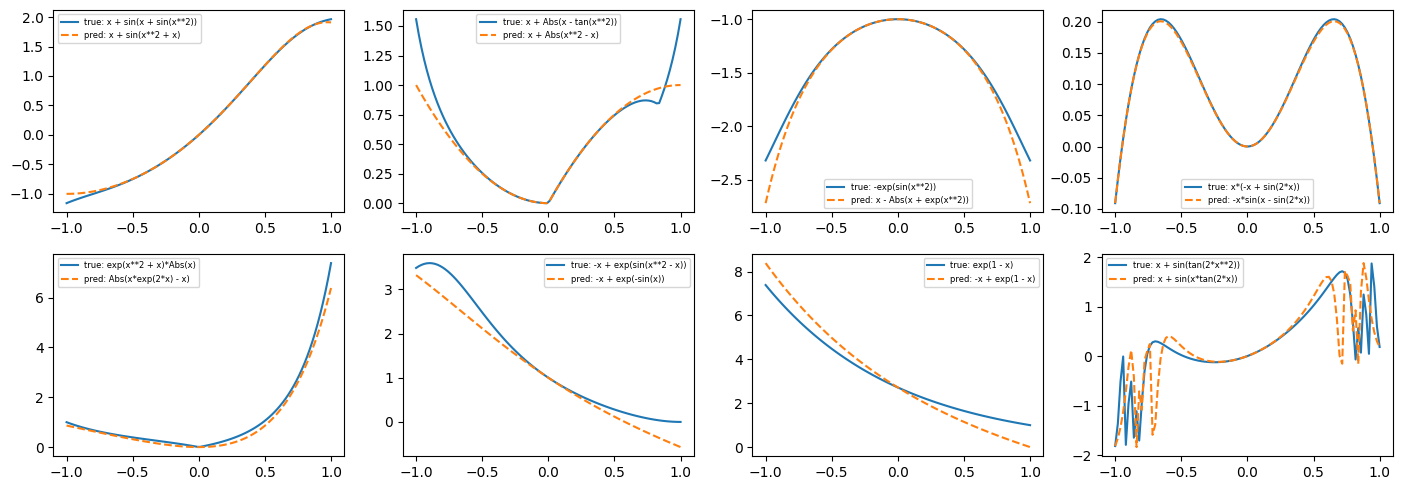

In [8]:
# plot a few predictions next to the truth
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, pred, true, y in zip(axes.ravel(), preds_a, eval_exprs, eval_y):
    ax.plot(x_grid, y, label=f"true: {true}")
    if pred is not None:
        ax.plot(x_grid, evaluate(pred, x_grid), "--", label=f"pred: {pred}")
    ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

## part b: symbolic regression with a pinn

in part a the network received 100 clean points. real measurements are usually sparse and noisy. here we pretend we only have 12 noisy samples of f(x).
we compare four inputs to the same trained network:

1. **clean data** (the best case, same as part a)
2. **linear interpolation** of the 12 noisy samples (the naive fix)
3. **plain neural net fit** (a small network fitted to the 12 samples, no physics)
4. **pinn** (the same small network, with an extra loss that forces dy/dx to match the known law s(x))

the pinn loss is

`loss = mean((net(x_obs) - y_obs)^2) + w * mean((d net / dx - s(x))^2)`

the first term fits the measurements. the second term is the ode residual, evaluated on 100 collocation points, with the derivative taken by autograd.

In [9]:
n_obs = 12
noise_std = 0.02
n_cases = 40

rng = np.random.RandomState(1)

# pick test expressions whose derivative is well behaved
cases = []
for i in test_ids:
    d_expr = sp.diff(exprs[i], x)
    d_vals = evaluate(d_expr, x_grid)
    if np.all(np.isfinite(d_vals)) and np.max(np.abs(d_vals)) < 50:
        cases.append((i, d_expr))
    if len(cases) == n_cases:
        break
print("cases:", len(cases))

cases: 40


In [10]:
class MlpNet(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        # tanh is smooth, so its derivative exists everywhere (relu would give a flat derivative)
        self.net = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, t):
        return self.net(t)


def fit_net(x_obs, y_obs, source_vals, phys_weight, steps=2500):
    # phys_weight = 0 gives the plain fit, phys_weight > 0 gives the pinn
    torch.manual_seed(0)
    net = MlpNet().double()
    opt = torch.optim.Adam(net.parameters(), lr=5e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)

    xo = torch.tensor(x_obs, dtype=torch.double)[:, None]
    yo = torch.tensor(y_obs, dtype=torch.double)[:, None]
    xc = torch.tensor(x_grid, dtype=torch.double)[:, None].requires_grad_(True)
    src = torch.tensor(source_vals, dtype=torch.double)[:, None]

    for _ in range(steps):
        opt.zero_grad()
        loss = ((net(xo) - yo) ** 2).mean()
        if phys_weight > 0:
            u = net(xc)
            du = torch.autograd.grad(u, xc, torch.ones_like(u), create_graph=True)[0]
            loss = loss + phys_weight * ((du - src) ** 2).mean()
        loss.backward()
        opt.step()
        sched.step()

    with torch.no_grad():
        return net(torch.tensor(x_grid, dtype=torch.double)[:, None]).numpy().ravel()


def as_input(y):
    return np.stack([x_grid, y], axis=1).astype(np.float32)

In [11]:
inputs = {"clean data": [], "interpolation": [], "plain net fit": [], "pinn": []}
true_exprs, true_y, extras = [], [], []

start = time.time()
for i, d_expr in cases:
    y_true = ys[i]
    x_obs = np.sort(rng.uniform(-1, 1, n_obs))
    y_obs = evaluate(exprs[i], x_obs) + rng.normal(0, noise_std, n_obs)
    source_vals = evaluate(d_expr, x_grid)

    y_interp = np.interp(x_grid, x_obs, y_obs)
    y_plain = fit_net(x_obs, y_obs, source_vals, phys_weight=0)
    y_pinn = fit_net(x_obs, y_obs, source_vals, phys_weight=1.0)

    inputs["clean data"].append(as_input(y_true))
    inputs["interpolation"].append(as_input(y_interp))
    inputs["plain net fit"].append(as_input(y_plain))
    inputs["pinn"].append(as_input(y_pinn))
    true_exprs.append(exprs[i])
    true_y.append(y_true)
    extras.append((x_obs, y_obs))

print(f"fitting {len(cases)} cases took {time.time() - start:.0f}s")

fitting 40 cases took 336s


In [12]:
print("reconstruction error on the grid (mean absolute error):")
for name, arrs in inputs.items():
    err = np.mean([np.mean(np.abs(a[:, 1] - y)) for a, y in zip(arrs, true_y)])
    print(f"  {name:<14} {err:.4f}")

print()
scores = {}
for name, arrs in inputs.items():
    preds = predict_exprs(model, torch.tensor(np.stack(arrs)))
    scores[name] = report(name, preds, true_exprs, true_y)

reconstruction error on the grid (mean absolute error):
  clean data     0.0000
  interpolation  0.1115
  plain net fit  0.0568
  pinn           0.0050

clean data             valid 100.0%   same form   0.0%   same curve  27.5%
interpolation          valid  97.5%   same form   0.0%   same curve   2.5%
plain net fit          valid  97.5%   same form   0.0%   same curve  10.0%
pinn                   valid 100.0%   same form   0.0%   same curve  27.5%


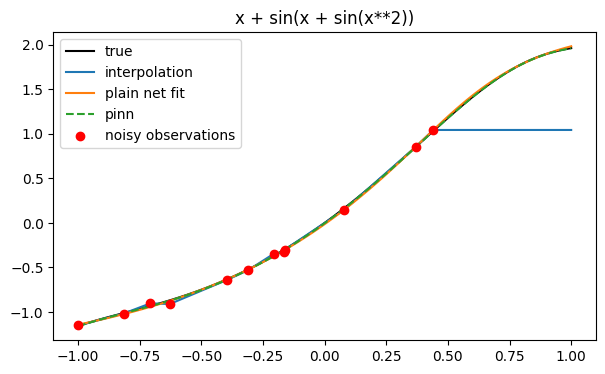

In [13]:
# look at one case in detail
k = 0
x_obs, y_obs = extras[k]
plt.figure(figsize=(7, 4))
plt.plot(x_grid, true_y[k], "k", label="true")
plt.plot(x_grid, inputs["interpolation"][k][:, 1], label="interpolation")
plt.plot(x_grid, inputs["plain net fit"][k][:, 1], label="plain net fit")
plt.plot(x_grid, inputs["pinn"][k][:, 1], "--", label="pinn")
plt.scatter(x_obs, y_obs, c="r", zorder=5, label="noisy observations")
plt.title(str(true_exprs[k]))
plt.legend()
plt.show()

## notes and limits

- the pinn here only works because we assumed the derivative law s(x) is known. if you have no equation, part a is the right tool.
- the symbolic regression network was trained on clean, dense data only. part b tests how much better the inputs become, not a new training run. training the network on noisy reconstructed inputs would likely help more.
- in part b the derivative of the true expression is computed with sympy to play the role of the known physics. in a real problem it would come from theory or from another measurement.
- ideas to try: change `n_obs` and `noise_std`, change the physics weight `phys_weight`, or replace `SeqFCN` with a transformer.